In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_selection import SelectKBest, f_regression, f_classif
from sklearn.preprocessing import LabelEncoder

sns.set_style('whitegrid')

# Load dataset hasil cleaning dari praktikum5
df = pd.read_csv('/content/drive/MyDrive/Praktikum_DM/cleaned_cafe_sales.csv')

df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Transaction Date
0,TXN_6234882,Cookie,4.000000,1.000000,4.000000,Credit Card,2023-01-01
1,TXN_4801947,Juice,1.000000,3.000000,3.000000,Digital Wallet,2023-01-01
2,TXN_8842223,Sandwich,5.000000,2.951766,14.758828,Digital Wallet,2023-01-01
3,TXN_5728991,Salad,3.029846,5.000000,15.149228,Unknown,2023-01-01
4,TXN_2192787,Sandwich,5.000000,4.000000,20.000000,Cash,2023-01-01


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8613 entries, 0 to 8612
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    8613 non-null   object 
 1   Item              8613 non-null   object 
 2   Quantity          8613 non-null   float64
 3   Price Per Unit    8613 non-null   float64
 4   Total Spent       8613 non-null   float64
 5   Payment Method    8613 non-null   object 
 6   Transaction Date  8613 non-null   object 
dtypes: float64(3), object(4)
memory usage: 471.2+ KB


Feature Selection bekerja pada data numerik


In [ ]:
# Pastikan kolom tanggal bertipe datetime
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

#Ekstrak fitur waktu dari Transaction Date
df['Month']       = df['Transaction Date'].dt.month
df['DayOfWeek']   = df['Transaction Date'].dt.dayofweek   # 0=Senin, 6=Minggu
df['DayOfMonth']  = df['Transaction Date'].dt.day
df['Hour']        = df['Transaction Date'].dt.hour

In [ ]:
# Label Encoding untuk kolom kategorikal
le = LabelEncoder()

df['Item_encoded']           = le.fit_transform(df['Item'])
df['PaymentMethod_encoded']  = le.fit_transform(df['Payment Method'])

print("Kolom setelah feature engineering:")
print(df.columns.tolist())
df.head()

Kolom setelah feature engineering:
['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Transaction Date', 'Month', 'DayOfWeek', 'DayOfMonth', 'Hour', 'Item_encoded', 'PaymentMethod_encoded']


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Transaction Date,Month,DayOfWeek,DayOfMonth,Hour,Item_encoded,PaymentMethod_encoded
0,TXN_6234882,Cookie,4.000000,1.000000,4.000000,Credit Card,2023-01-01,1,6,1,0,2,1
1,TXN_4801947,Juice,1.000000,3.000000,3.000000,Digital Wallet,2023-01-01,1,6,1,0,3,2
2,TXN_8842223,Sandwich,5.000000,2.951766,14.758828,Digital Wallet,2023-01-01,1,6,1,0,5,2
3,TXN_5728991,Salad,3.029846,5.000000,15.149228,Unknown,2023-01-01,1,6,1,0,4,3
4,TXN_2192787,Sandwich,5.000000,4.000000,20.000000,Cash,2023-01-01,1,6,1,0,5,0


C. Feature Selection — Pearson Correlation

Metode 1: Pearson Correlation
Konsep Korelasi Pearson mengukur kekuatan dan arah hubungan linier antara dua variabel numerik. Nilai berkisar antara -1 hingga +1:

Dalam feature selection, korelasi digunakan untuk:

Menemukan fitur yang sangat berkorelasi dengan target (fitur penting)
Mendeteksi multikolinearitas antar fitur (fitur redundan)

In [ ]:
# Pilih kolom numerik yang akan dianalisis
numeric_features = [
    'Quantity', 'Price Per Unit', 'Total Spent',
    'Month', 'DayOfWeek', 'DayOfMonth',
    'Item_encoded', 'PaymentMethod_encoded'
]

df_numeric = df[numeric_features]

# Hitung Correlation Matrix
corr_matrix = df_numeric.corr(method='pearson')

print('Pearson Correlation Matrix:')
corr_matrix.round(3)

Pearson Correlation Matrix:


,Quantity,Price Per Unit,Total Spent,Month,DayOfWeek,DayOfMonth,Item_encoded,PaymentMethod_encoded
Quantity,1.000,0.002,0.706,-0.004,0.001,-0.007,0.006,-0.006
Price Per Unit,0.002,1.000,0.644,-0.013,-0.001,0.021,0.228,-0.023
Total Spent,0.706,0.644,1.000,-0.006,0.004,0.005,0.152,-0.019
Month,-0.004,-0.013,-0.006,1.000,0.018,0.001,-0.007,-0.011
DayOfWeek,0.001,-0.001,0.004,0.018,1.000,-0.008,-0.009,0.001
DayOfMonth,-0.007,0.021,0.005,0.001,-0.008,1.000,0.015,-0.005
Item_encoded,0.006,0.228,0.152,-0.007,-0.009,0.015,1.000,0.002
PaymentMethod_encoded,-0.006,-0.023,-0.019,-0.011,0.001,-0.005,0.002,1.000


In [ ]:
# Pilih kolom numerik yang akan dianalisis
numeric_features = [
    'Quantity', 'Price Per Unit', 'Total Spent',
    'Month', 'DayOfWeek', 'DayOfMonth',
    'Item_encoded', 'PaymentMethod_encoded'
]

df_numeric = df[numeric_features]

# Hitung Correlation Matrix
corr_matrix = df_numeric.corr(method='spearman')

print('Pearson Correlation Matrix:')
corr_matrix.round(3)

Pearson Correlation Matrix:


,Quantity,Price Per Unit,Total Spent,Month,DayOfWeek,DayOfMonth,Item_encoded,PaymentMethod_encoded
Quantity,1.000,0.001,0.723,-0.004,0.002,-0.008,0.006,-0.005
Price Per Unit,0.001,1.000,0.643,-0.013,-0.001,0.018,0.235,-0.021
Total Spent,0.723,0.643,1.000,-0.010,0.004,0.006,0.128,-0.019
Month,-0.004,-0.013,-0.010,1.000,0.018,0.001,-0.008,-0.011
DayOfWeek,0.002,-0.001,0.004,0.018,1.000,-0.007,-0.009,0.001
DayOfMonth,-0.008,0.018,0.006,0.001,-0.007,1.000,0.015,-0.005
Item_encoded,0.006,0.235,0.128,-0.008,-0.009,0.015,1.000,0.001
PaymentMethod_encoded,-0.005,-0.021,-0.019,-0.011,0.001,-0.005,0.001,1.000


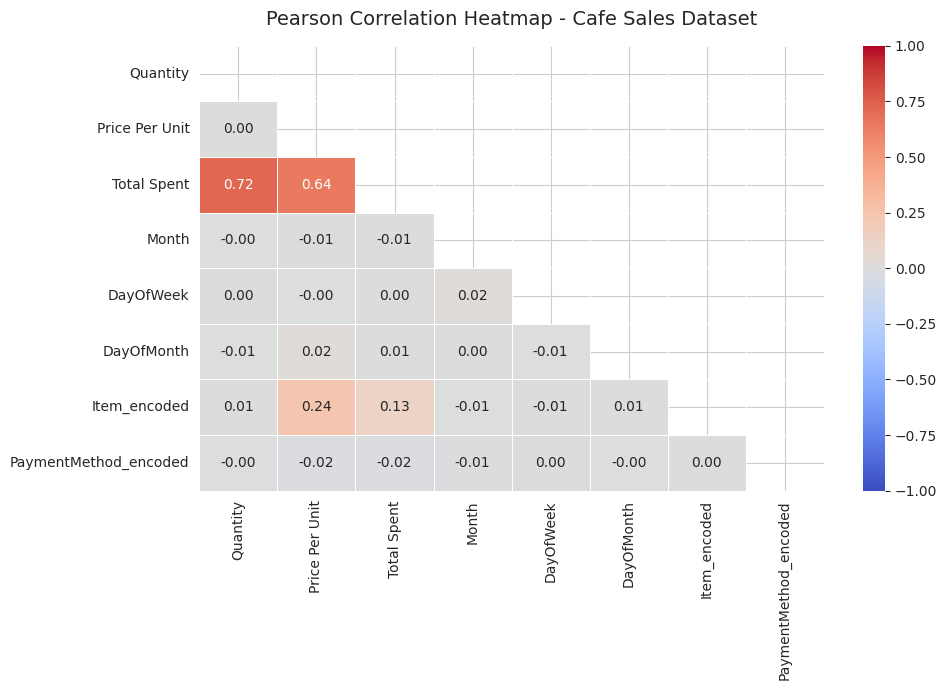

In [ ]:
# Visualisasi: Heatmap Korelasi
plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # sembunyikan segitiga atas

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    mask=mask,
    linewidths=0.5,
    vmin=-1, vmax=1
)

plt.title('Pearson Correlation Heatmap - Cafe Sales Dataset', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [ ]:
# Korelasi Setiap Fitur Terhadap Target (Total Spent)
target = 'Total Spent'
corr_with_target = (
    df_numeric.corr(method='pearson')[target]
    .drop(target)              # hapus korelasi target dengan dirinya sendiri
    .sort_values(key=abs, ascending=False)
)

print('Korelasi fitur dengan target (Total Spent):')
print(corr_with_target.to_string())

Korelasi fitur dengan target (Total Spent):
Quantity                 0.705991
Price Per Unit           0.644480
Item_encoded             0.151638
PaymentMethod_encoded   -0.019353
Month                   -0.005859
DayOfMonth               0.004627
DayOfWeek                0.004408


In [ ]:
# Seleksi Fitur Berdasarkan Threshold Korelasi
THRESHOLD =0.1 # Fitur dengan [korelasi] >- threshold dianggap relevan

selected_by_pearson = corr_with_target[abs(corr_with_target) >= THRESHOLD].index.tolist()
dropped_by_pearson  = corr_with_target[abs(corr_with_target) <  THRESHOLD].index.tolist()

print(f'Threshold korelasi : |r| >= {THRESHOLD}')
print(f'\nFitur DIPILIH ({len(selected_by_pearson)}) : {selected_by_pearson}')
print(f'Fitur DIBUANG ({len(dropped_by_pearson)}) : {dropped_by_pearson}')

Threshold korelasi : |r| >= 0.1

Fitur DIPILIH (3) : ['Quantity', 'Price Per Unit', 'Item_encoded']
Fitur DIBUANG (4) : ['PaymentMethod_encoded', 'Month', 'DayOfMonth', 'DayOfWeek']


# D. Feature Selection - Metode 2 : SelectKBest

In [ ]:
X = df_numeric.drop(['Total Spent'], axis=1)
y = df_numeric['Total Spent']

print('Shape X:', X.shape)
print('Shape y:', y.shape)

Shape X: (8613, 7)
Shape y: (8613,)


In [ ]:
# Hitung F-Score dan p-value untuk SEMUA fitur
selector_all = SelectKBest(score_func=f_regression, k='all')
selector_all.fit(X, y)

# Buat DataFrame ringkasan
skb_result = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': selector_all.scores_,
    'p-value': selector_all.pvalues_
}).sort_values(by='F-Score', ascending=False).reset_index(drop=True)

# Tandai signifikansi (p-value < 0.05)
skb_result['Signifikan'] = skb_result['p-value'].apply(
    lambda x: 'Ya' if x < 0.05 else 'Tidak'
)

print('Skor SelectKBest (f_regression) - semua fitur : ')
skb_result.round(4)

Skor SelectKBest (f_regression) - semua fitur : 


,Feature,F-Score,p-value,Signifikan
0,Quantity,8556.8652,0.0000,Ya
1,Price Per Unit,6117.5863,0.0000,Ya
2,Item_encoded,202.6626,0.0000,Ya
3,PaymentMethod_encoded,3.2265,0.0725,Tidak
4,Month,0.2956,0.5867,Tidak
5,DayOfMonth,0.1844,0.6677,Tidak
6,DayOfWeek,0.1673,0.6825,Tidak


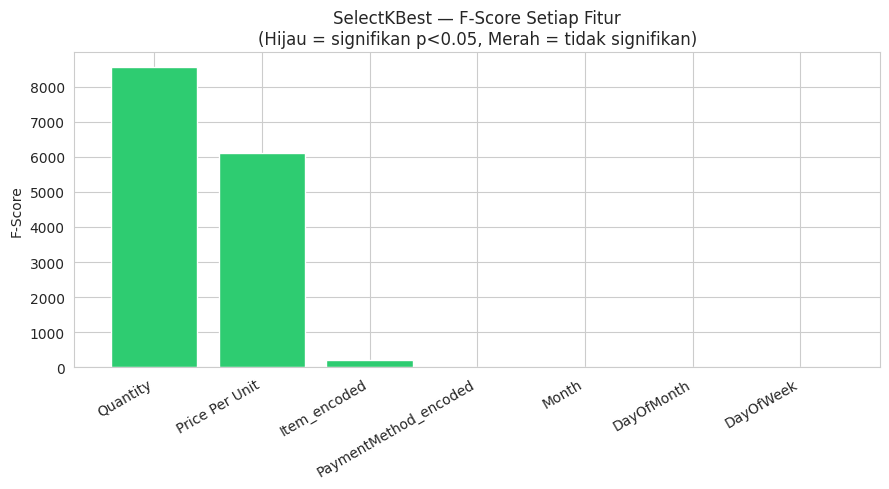

In [ ]:
# Visualisasi F-Score
plt.figure(figsize=(9, 5))

# Menentukan warna batang berdasarkan p-value (Hijau jika signifikan < 0.05)
bar_colors = ['#2ecc71' if p < 0.05 else '#e74c3c'
              for p in skb_result['p-value']]

# Membuat bar chart
plt.bar(skb_result['Feature'], skb_result['F-Score'], color=bar_colors)

# Mengatur tampilan sumbu x
plt.xticks(rotation=30, ha='right')

# Menambahkan judul dan label
plt.title('SelectKBest — F-Score Setiap Fitur\n(Hijau = signifikan p<0.05, Merah = tidak signifikan)', fontsize=12)
plt.ylabel('F-Score')

# Penyesuaian tata letak agar tidak terpotong
plt.tight_layout()

# Menampilkan grafik
plt.show()

In [ ]:
# Pilih K Fitur Terbaik
K = 4  # <- ubah nilai K sesuai kebutuhan

selector_k = SelectKBest(score_func=f_regression, k=K)
X_selected = selector_k.fit_transform(X, y)

# Nama fitur yang terpilih
selected_mask = selector_k.get_support()
selected_features = [col for col, sel in zip(X.columns, selected_mask) if sel]
dropped_features = [col for col, sel in zip(X.columns, selected_mask) if not sel]

print(f'SelectKBest dengan K = {K}')
print(f'\nFitur TERPILIH ({len(selected_features)}) : {selected_features}')
print(f'Fitur TIDAK dipilih ({len(dropped_features)}) : {dropped_features}')
print(f'\nShape X setelah SelectKBest : {X_selected.shape}')

SelectKBest dengan K = 4

Fitur TERPILIH (4) : ['Quantity', 'Price Per Unit', 'Item_encoded', 'PaymentMethod_encoded']
Fitur TIDAK dipilih (3) : ['Month', 'DayOfWeek', 'DayOfMonth']

Shape X setelah SelectKBest : (8613, 4)


In [ ]:
# Tabel Perbandingan
comparison = pd.DataFrame({
    "Fitur"           : X.columns,
    "Pearson |r|"     : [round(abs(corr_with_target.get(f, 0)), 4) for f in X.columns],
    "Pearson Dipilih" : ['dipilih' if f in selected_by_pearson else 'tidak dipilih' for f in X.columns],
    "SKB F-Score"     : [round(selector_all.scores_[i], 2) for i, f in enumerate(X.columns)],
    "SKB P-Value"     : [round(selector_all.pvalues_[i], 4) for i, f in enumerate(X.columns)],
    f'SKB Top-{K}'    : ['dipilih' if f in selected_features else 'tidak dipilih' for f in X.columns],
}).sort_values('SKB F-Score', ascending=False)

print('Perbandingan Pearson Correlation vs SelectKBest:')
comparison

Perbandingan Pearson Correlation vs SelectKBest:


,Fitur,Pearson |r|,Pearson Dipilih,SKB F-Score,SKB P-Value,SKB Top-4
0,Quantity,0.7060,dipilih,8556.87,0.0000,dipilih
1,Price Per Unit,0.6445,dipilih,6117.59,0.0000,dipilih
5,Item_encoded,0.1516,dipilih,202.66,0.0000,dipilih
6,PaymentMethod_encoded,0.0194,tidak dipilih,3.23,0.0725,dipilih
2,Month,0.0059,tidak dipilih,0.30,0.5867,tidak dipilih
4,DayOfMonth,0.0046,tidak dipilih,0.18,0.6677,tidak dipilih
3,DayOfWeek,0.0044,tidak dipilih,0.17,0.6825,tidak dipilih
